n_examples=10  sent=(10, 5196)  received=(10, 5196)
mod=qpsk  dc_offset_A=0.122


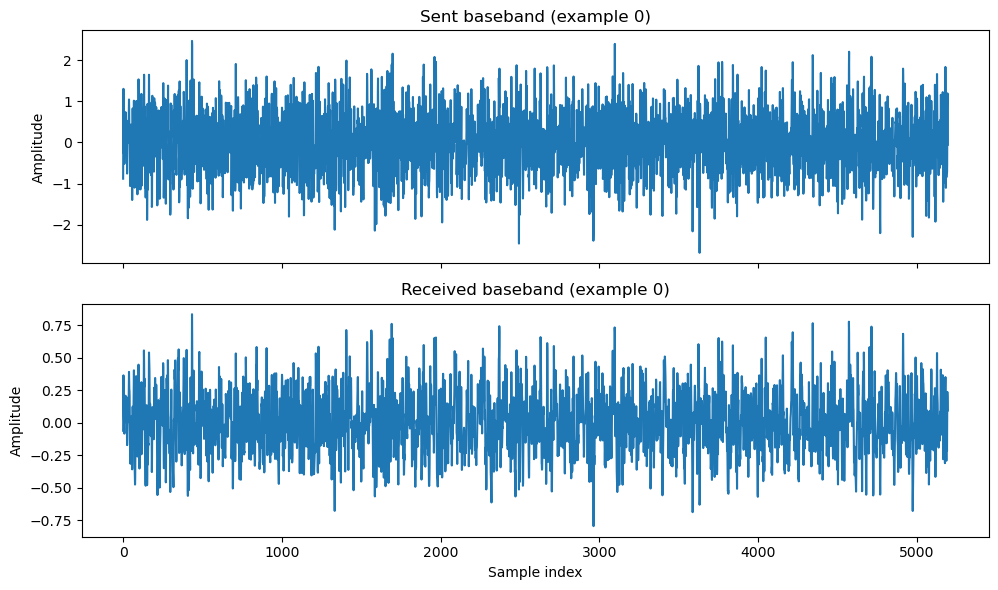

In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

def load_and_plot_first(dataset_path):
    g = zarr.open_group(dataset_path, mode="r")
    sent = np.asarray(g["sent_baseband"])
    received = np.asarray(g["received_baseband"])
    print(f"n_examples={sent.shape[0]}  sent={sent.shape}  received={received.shape}")
    print(f"mod={g.attrs.get('modulation_format')}  dc_offset_A={g.attrs.get('dc_offset_A')}")

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(sent[0]);     ax[0].set_title("Sent baseband (example 0)");     ax[0].set_ylabel("Amplitude")
    ax[1].plot(received[0]); ax[1].set_title("Received baseband (example 0)"); ax[1].set_ylabel("Amplitude")
    ax[1].set_xlabel("Sample index")
    plt.tight_layout()
    plt.show()
    return sent, received

sent, received = load_and_plot_first("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.122A_fmin300000_fmax1.299e+07_20260615_1430.zarr")


In [ ]:
from modules.models import TCN_channel

# Toy model for calculating receptive field

tcn = TCN_channel(nlayers=2, dilation_base=2, kernel_size=5, hidden_channels=32)
print(f"Receptive field of TCN: {tcn.receptive_field}")

Receptive field of TCN: 13
